In [13]:
import json
import numpy as np
import nltk
from nltk.stem import WordNetLemmatizer
import pickle
import random
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ibrahim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ibrahim\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ibrahim\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ibrahim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Data Loading and Preprocessing

In [14]:
# Load intents
with open('intents.json') as file:
    intents = json.load(file)

words = []
classes = []
documents = []
ignore_letters = ['?', '!', '.', ',']

# Preprocess intents
for intent in intents['intents']:
    for pattern in intent['patterns']:
        # Tokenize each word
        word_list = nltk.word_tokenize(pattern)
        words.extend(word_list)
        # Add to documents in our corpus
        documents.append((word_list, intent['tag']))
        # Add to our classes list
        if intent['tag'] not in classes:
            classes.append(intent['tag'])

# Lemmatize and lower each word and remove duplicates
words = [lemmatizer.lemmatize(w.lower()) for w in words if w not in ignore_letters]
words = sorted(list(set(words)))

# Sort classes
classes = sorted(list(set(classes)))

print(f"Loaded {len(documents)} documents")
print(f"Classes: {len(classes)}")
print(f"Unique lemmatized words: {len(words)}")

# Save words and classes for later use in the Flask app
pickle.dump(words, open('words.pkl', 'wb'))
pickle.dump(classes, open('classes.pkl', 'wb'))

Loaded 197 documents
Classes: 51
Unique lemmatized words: 139


## 2. Feature Engineering

In [15]:
# Create training data
training = []
output_empty = [0] * len(classes)

for doc in documents:
    bag = []
    word_patterns = doc[0]
    word_patterns = [lemmatizer.lemmatize(word.lower()) for word in word_patterns]
    for word in words:
        bag.append(1) if word in word_patterns else bag.append(0)

    output_row = list(output_empty)
    output_row[classes.index(doc[1])] = 1
    training.append([bag, output_row])

# Shuffle training data
random.shuffle(training)

# Separate features and labels
train_x = np.array([item[0] for item in training])
train_y = np.array([item[1] for item in training])

print(f"Training data shape: X={train_x.shape}, y={train_y.shape}")

Training data shape: X=(197, 139), y=(197, 51)


## 3. Deep Learning Model Building

In [16]:
# Build the model
model = Sequential()
model.add(Dense(256, input_shape=(len(train_x[0]),), activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))


model.add(Dense(len(train_y[0]), activation='softmax'))

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 51)             │         1,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,051 (218.95 KB)

 Trainable params: 56,051 (218.95 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training

In [17]:
# Train model
hist = model.fit(train_x, train_y, epochs=200, batch_size=5, verbose=1, validation_split=0.1)

# Save model
model.save('chatbot_model.h5')
print("Model created and saved to chatbot_model.h5")

Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0226 - loss: 3.9261 - val_accuracy: 0.0500 - val_loss: 3.8894
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0734 - loss: 3.8762 - val_accuracy: 0.0000e+00 - val_loss: 3.8650
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0960 - loss: 3.7718 - val_accuracy: 0.0000e+00 - val_loss: 3.8244
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0791 - loss: 3.6554 - val_accuracy: 0.0000e+00 - val_loss: 3.7531
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0904 - loss: 3.4651 - val_accuracy: 0.0000e+00 - val_loss: 3.6683
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0960 - loss: 3.2991 - val_accuracy: 0.0500 - val_loss: 3.6047
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1695 - loss: 3.0842 - val_accuracy: 0.1000 - val_loss: 3.5563
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1864 - loss: 2.8907 - val_accu

Model created and saved to chatbot_model.h5


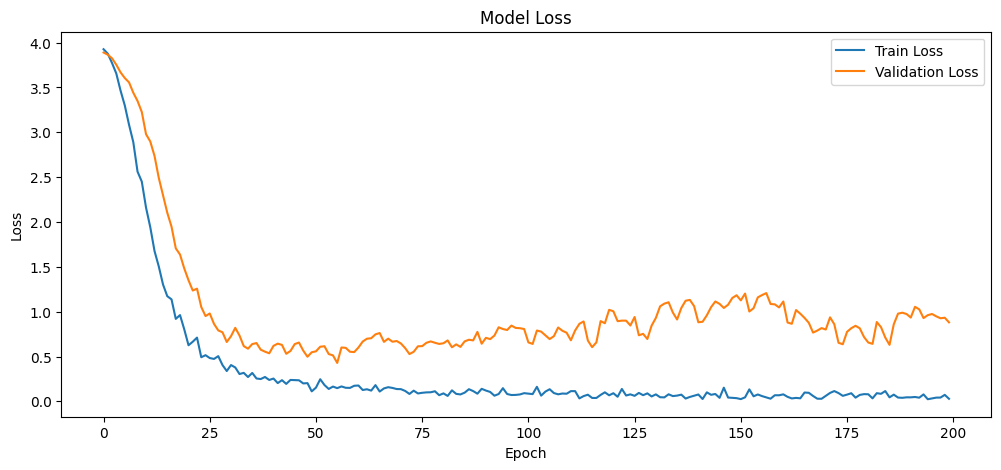

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.show()

In [19]:
def clean_up_sentence(sentence):
    sentence_words = nltk.word_tokenize(sentence)
    sentence_words = [lemmatizer.lemmatize(word.lower()) for word in sentence_words]

    return sentence_words

In [20]:
def bow(sentence, words, show_details=True):
    sentence_words = clean_up_sentence(sentence)

    bag = [0] * len(words)
    for s in sentence_words:
        for i, w in enumerate(words):
            if w == s:
                bag[i] = 1
                if show_details:
                    print ("found in bag: %s" % w)

    return(np.array(bag))

In [21]:
def predict_class(sentence, model):
    p = bow(sentence, words,show_details=False)
    res = model.predict(np.array([p]))[0]
    ERROR_THRESHOLD = 0.25
    results = [[i, r] for i, r in enumerate(res) if r > ERROR_THRESHOLD]

    results.sort(key=lambda x: x[1], reverse=True)
    return_list = []
    for r in results:
        return_list.append({"intent": classes[r[0]], "probability": str(r[1])})

    return return_list

In [22]:
def getResponse(ints, intents_json):
    tag = ints[0]['intent']
    list_of_intents = intents_json['intents']
    for i in list_of_intents:
        if(i['tag']== tag):
            result = random.choice(i['responses'])
            break

    return result

In [23]:
def chatbot_response(msg):
    ints = predict_class(msg, model)
    res = getResponse(ints, intents)
    return res

In [60]:
chatbot_response('Recommend a book in fiction')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


{'Book': 'Gilead',
 'Feedback': 'A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives. John Ames is a preacher, the son of a preacher and the grandson (both maternal and paternal) of preachers. It’s 1956 in Gilead, Iowa, towards the end of the Reverend Ames’s life, and he is absorbed in recording his family’s story, a legacy for the young son he will never see grow up. Haunted by his grandfather’s presence, John tells of the rift between his grandfather and his father: the elder, an angry visionary who fought for the abolitionist cause, and his son, an ardent pacifist. He is troubled, too, by his prodigal namesake, Jack (John Ames) Boughton, his best friend’s lost son who returns to Gilead searching for forgiveness and redemption. Told in John Ames’s joyous, rambling voice that finds beauty, humour and truth in the smallest of life’s details, Gilead is a song of celebration and acceptance of the